# Interactive Visualization of 3D Gaussian Splats with nerfstudio's gsplat renderer

Here we show how to use Kaolin's **camera conversion**, **ply/USD readers** and **interactive ipython visualizer** to view a 3D Guassian Splat model rendered with [nerfstudio's gsplat library](https://github.com/nerfstudio-project/gsplat). 

Specifically, we'll show how to interactively control aligned mesh and splat renderings using same camera conventions.

In [1]:
import copy
import gsplat.rendering
import ipywidgets
import ipyevents
import logging
import math
import os
import torch

import kaolin
from kaolin.render.camera import kaolin_camera_to_gsplat_nerfstudio
from kaolin.utils.bundled_data import SCANNED_TOYS_PATH, SCANNED_TOYS_NAMES, download_scanned_toys_dataset
from kaolin.utils.log import log_tensor
from kaolin.visualize.ipython import quick_viz

%load_ext autoreload
%autoreload 2
%matplotlib inline

kaolin.utils.log.default_log_setup(logging.DEBUG)
    
device = 'cuda'

2026-04-09 12:12:55,124|    INFO|kaolin.utils.log| Logging to stdout


### Preliminaries

Let's download sample data and install gsplat. Note that our data contains an aligned **3D Gaussian Splat** model and a **low-poly mesh** approximation.

In [2]:
download_scanned_toys_dataset()  # only re-downloads if needed

'/home/mshugrina/Documents/Coding/Kaolin/DevAux/kaolin/sample_data/scanned_toys'

In [3]:
!pip install -q matplotlib
!pip install gsplat

### Loading Data

Now let's load a gaussian splat model and mesh into torch tensors. 

We'll examine tensors and their stats: note that gaussian `positions` and mesh `vertices` have similar stats, - as these two are already aligned.

In [4]:
TOY_NAME = SCANNED_TOYS_NAMES[0]
GSMODEL = os.path.join(SCANNED_TOYS_PATH, f'{TOY_NAME}.ply')  # USD also downloaded and supported for splats
MESH = os.path.join(SCANNED_TOYS_PATH, f'mesh.{TOY_NAME}.usd')

gsmodel = kaolin.io.import_gaussiancloud(GSMODEL)
gsmodel = {k: v.to(device) for k, v in gsmodel.items()}
log_tensor(gsmodel, 'gsmodel', print_stats=True)

mesh = kaolin.io.import_mesh(MESH).to(device)
print(mesh.to_string(print_stats=True))

2026-04-09 12:13:02,599|   DEBUG|kaolin.utils.log| gsmodel[positions]:: [155290, 3] (torch.float32)[cuda:0]  - [min -0.1956, max 0.9822, mean 0.1267] 
gsmodel[orientations]:: [155290, 4] (torch.float32)[cuda:0]  - [min -0.9999, max 0.9122, mean -0.3894] 
gsmodel[scales]:: [155290, 3] (torch.float32)[cuda:0]  - [min 0.0000, max 0.0560, mean 0.0015] 
gsmodel[opacities]:: [155290] (torch.float32)[cuda:0]  - [min 0.0014, max 1.0000, mean 0.5046] 
gsmodel[sh_coeff]:: [155290, 16, 3] (torch.float32)[cuda:0]  - [min -2.1986, max 3.4715, mean -0.0128] 
SurfaceMesh object with batching strategy NONE
            vertices: [944, 3] (torch.float32)[cuda:0]  - [min -0.1950, max 0.9465, mean 0.1802] 
               faces: [1884, 3] (torch.int64)[cuda:0]  - [min 0.0000, max 943.0000, mean 468.2823] 
        face_normals: [1884, 3, 3] (torch.float32)[cuda:0]  - [min -0.9999, max 0.9998, mean -0.0010] 
                 uvs: [5652, 2] (torch.float32)[cuda:0]  - [min 0.0000, max 1.0000, mean 0.4924] 
   

### Basic Rendering (Aligned Mesh and Splats)

Now we'll use Kaolin's `easy_render` module to render mesh using Kaolin camera, and we will use kaolin's converter to render using nerfstudio gsplat library in the same coordinate frame.

/home/mshugrina/anaconda3/envs/kaolin-devaux/lib/python3.10/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


2026-04-09 12:13:21,327|   DEBUG|kaolin.utils.log| colors: [1, 512, 512, 3] (torch.float32)[cuda:0]  - [min 0.0000, max 0.9453, mean 0.0509] 
2026-04-09 12:13:21,330|   DEBUG|kaolin.utils.log| alphas: [1, 512, 512, 1] (torch.float32)[cuda:0]  - [min 0.0000, max 0.9999, mean 0.1364] 
2026-04-09 12:13:21,341|   DEBUG|kaolin.rep.surface_mesh| Automatically computing face_uvs based on ['uvs', 'face_uvs_idx']
2026-04-09 12:13:21,432|   DEBUG|kaolin.rep.surface_mesh| Automatically computing face_tangents based on ['faces', 'vertex_tangents']
2026-04-09 12:13:21,433|   DEBUG|kaolin.rep.surface_mesh| Automatically computing vertex_tangents based on ['faces', 'face_vertices', 'face_uvs', 'vertex_normals']
2026-04-09 12:13:21,435|   DEBUG|kaolin.rep.surface_mesh| Automatically computing face_vertices based on ['faces', 'vertices']
2026-04-09 12:13:21,439|   DEBUG|kaolin.rep.surface_mesh| Automatically computing vertex_normals based on ['faces', 'face_normals']
2026-04-09 12:13:22,286|   DEBUG|ka

Text(0.5, 1.0, '3D Gaussian Splat Rendering vs. Aligned Low-Poly Mesh')

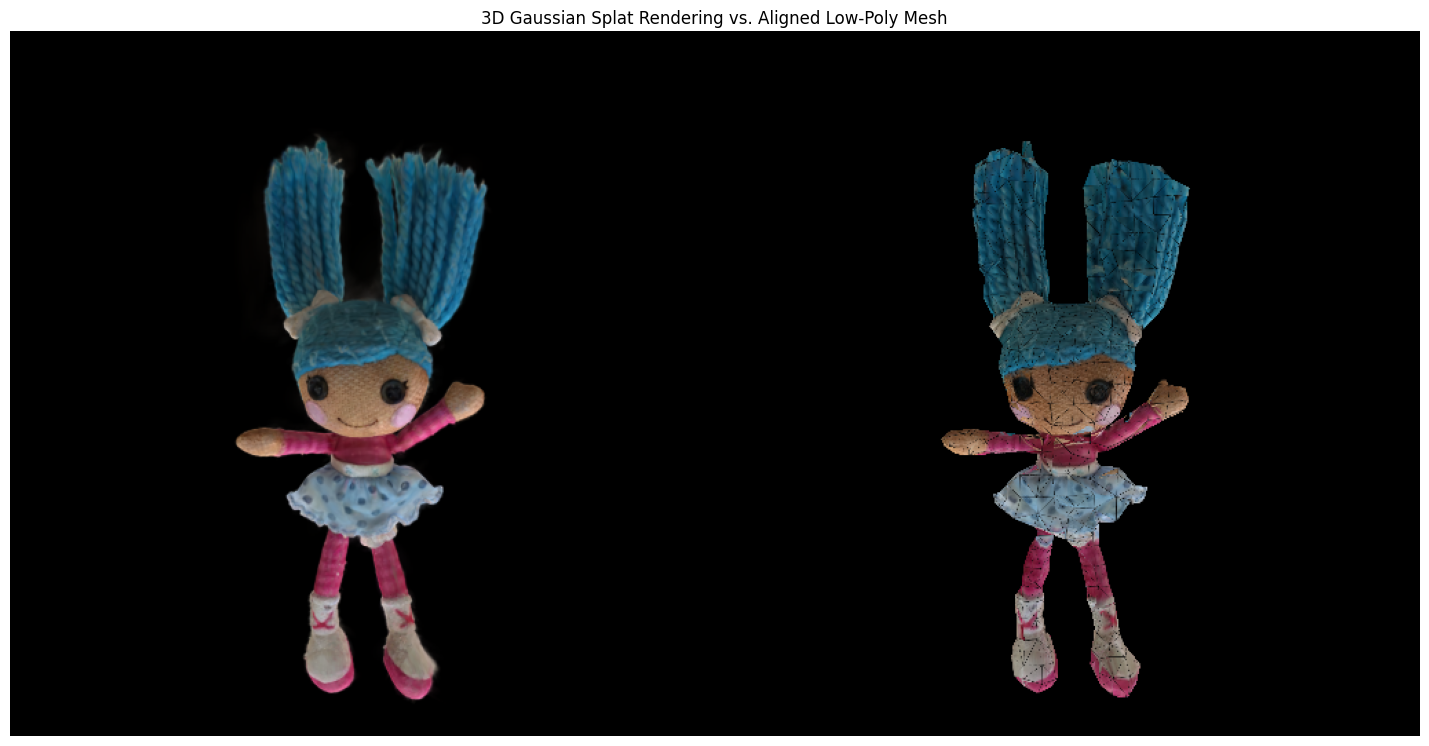

In [6]:
def render_with_gsplat(kal_cam, gsmodel):
    gsplat_cam_params = kaolin_camera_to_gsplat_nerfstudio(kal_cam)
    render_colors, render_alphas, info = gsplat.rendering.rasterization(
            gsmodel['positions'],  # [N, 3]
            gsmodel['orientations'],  # [N, 4]
            gsmodel['scales'],  # [N, 3]
            gsmodel['opacities'],  # [N]
            gsmodel['sh_coeff'],  # [N, S, 3]
            sh_degree=3,  # TODO: fix when we have gaussians class
            **gsplat_cam_params)
    return render_colors, render_alphas, info

kaolin_cam = kaolin.render.camera.Camera.from_args(
     eye=mesh.vertices.mean(dim=0) + torch.tensor([0, -1.3, 0], device=device), at=mesh.vertices.mean(dim=0), up=torch.tensor([0., 0.0, 1.0], device=device),
     fov=math.pi * 50 / 180, height=512, width=512).to(device)

colors, alphas, info = render_with_gsplat(kaolin_cam, gsmodel)
log_tensor(colors, 'colors', print_stats=True)
log_tensor(alphas, 'alphas', print_stats=True)

mesh_render = kaolin.render.easy_render.render_mesh(kaolin_cam, mesh)
log_tensor(mesh_render, 'mesh_render', print_stats=True)

kaolin.visualize.ipython.quick_viz(
    torch.cat([colors, mesh_render[kaolin.render.easy_render.RenderPass.albedo]], dim=0).permute(0, 3, 1, 2), inches=20).set_title('3D Gaussian Splat Rendering vs. Aligned Low-Poly Mesh')

### Interactive Visualization

Now we'll use Kaolin's ipython utility `IpyTurntableVisualizer` to allow interactive control of camera.

In [7]:
def tst_render(in_cam):
    colors, _, _ = render_with_gsplat(in_cam, gsmodel)
    colors = (colors[0, ...] * 255).clip(0, 255).to(torch.uint8)
    return colors

def tst_render_lowres(in_cam):
    new_cam = copy.deepcopy(in_cam)
    new_cam.width = in_cam.width // 4
    new_cam.height = in_cam.height // 4
    return tst_render(new_cam)

visualizer = kaolin.visualize.IpyTurntableVisualizer(
    kaolin_cam.height, kaolin_cam.width, copy.deepcopy(kaolin_cam), tst_render, fast_render=tst_render_lowres,
    max_fps=24, world_up_axis=1, focus_at=torch.zeros((3,), device=device))
visualizer.show()


Canvas(height=512, width=512)

Output()